# Markov Chains & Hidden Markov Models — From First Principles

> *"The future depends on the past only through the present."*

This notebook builds **Markov Chains** and **Hidden Markov Models (HMMs)** from the ground up:
the math, the intuition, and `numpy` implementations of the two algorithms you are most
likely to be quizzed on — the **Forward algorithm** and the **Viterbi algorithm**.

We'll anchor everything in a quant-flavored running example: a market that secretly switches
between **Bull** and **Bear** regimes, while we only get to observe noisy daily returns.

---

### 🎯 Quant-interview radar

Throughout I'll flag concepts with a **🎯 Quant flag** when they show up frequently in
quantitative trading interviews. The big three for this topic:

1. **The Markov property** — being able to state it precisely in one sentence.
2. **Stationary distributions** — "what fraction of time does the chain spend in each state?"
3. **HMMs for regime detection** — bull/bear regime switching is a classic modeling question.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

# A consistent color palette we'll reuse everywhere
C = {
    "blue":  "steelblue",
    "red":   "tomato",
    "green": "mediumseagreen",
    "orange":"darkorange",
    "navy":  "navy",
}

rng = np.random.default_rng(42)
print("Setup complete.")

Setup complete.


---
## 1 · The Markov Property — the one idea everything rests on

Imagine you're tracking the **weather**. To predict tomorrow, how much of history do you need?
A *full* model would condition on everything:

$$
P(X_{t+1} \mid X_t, X_{t-1}, X_{t-2}, \dots, X_0)
$$

That's hopeless — the history grows forever. A **Markov chain** makes one bold simplifying bet:

$$
\boxed{\;P(X_{t+1} \mid X_t, X_{t-1}, \dots, X_0) = P(X_{t+1} \mid X_t)\;}
$$

> **Key insight:** The present state $X_t$ is a *sufficient summary* of the entire past.
> Once you know where you are **right now**, the road that brought you here tells you nothing
> extra about where you'll go next. The present "screens off" the past from the future.

Think of a board game like Monopoly: to know your probabilities for the next square, you only
need your **current square** and the dice — not the entire log of every roll that got you there.

| Symbol | Meaning |
| --- | --- |
| $X_t$ | the **state** at time $t$ (e.g. "Sunny", "Rainy") |
| $\mathcal{S} = \{1, \dots, N\}$ | the finite set of $N$ possible states |
| $P(X_{t+1} \mid X_t)$ | the **transition** probability — the engine of the chain |

**🎯 Quant flag.** Interviewers love asking you to *state the Markov property in one sentence*
and then to spot when a real process **violates** it (e.g. momentum/autocorrelation in returns
means "today's price alone" may not screen off the past — a pure random walk is Markov, but many
trading signals deliberately exploit non-Markov structure).


---
## 2 · The Transition Matrix — the chain's DNA

If there are $N$ states, all the transition probabilities pack neatly into an $N \times N$
**transition matrix** $P$:

$$
P_{ij} = P(X_{t+1} = j \mid X_t = i)
$$

Read it as: *"row $i$ tells you where you go **from** state $i$."*

Because from state $i$ you must land **somewhere**, every **row sums to 1**:

$$
\sum_{j} P_{ij} = 1 \quad \text{for every } i.
$$

> **Key insight:** A transition matrix is just a stack of conditional probability
> distributions — one per row. Each row is a little "where to next?" lottery for that state.

Let's build a weather chain with states **Sunny (0)** and **Rainy (1)**. Suppose sunny days tend
to persist (90% stay sunny) and rainy days are a bit stickier still (50/50... let's say rainy
clears up half the time).


In [2]:
states = ["Sunny", "Rainy"]

# Row i = distribution over next state, given we're currently in state i
#                 ->Sunny  ->Rainy
P = np.array([[0.90,   0.10],    # from Sunny
              [0.50,   0.50]])   # from Rainy

assert np.allclose(P.sum(axis=1), 1.0), "Each row must sum to 1!"
print("Transition matrix P:\n", P)
print("\nRow sums (must all be 1):", P.sum(axis=1))

Transition matrix P:
 [[0.9 0.1]
 [0.5 0.5]]

Row sums (must all be 1): [1. 1.]


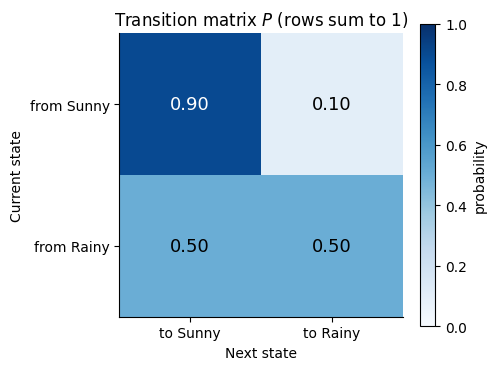

In [3]:
# Visualize the transition matrix as a heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center",
                color="white" if P[i, j] > 0.5 else "black", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"to {s}" for s in states])
ax.set_yticks([0, 1]); ax.set_yticklabels([f"from {s}" for s in states])
ax.set_xlabel("Next state"); ax.set_ylabel("Current state")
ax.set_title("Transition matrix $P$ (rows sum to 1)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="probability")
plt.tight_layout()
plt.show()

---
## 3 · Simulating the chain — watching it walk

To *sample* a trajectory we just repeatedly roll the current row's lottery:

1. Start in some state $X_0$.
2. Look at row $X_t$ of $P$, draw the next state from that distribution.
3. Repeat.

This is the simplest "from scratch" Markov-chain engine you can write.


In [4]:
def simulate_markov(P, start, n_steps, rng):
    '''Sample a state sequence of length n_steps from a Markov chain.'''
    N = P.shape[0]
    seq = np.empty(n_steps, dtype=int)
    seq[0] = start
    for t in range(1, n_steps):
        # row P[seq[t-1]] is the conditional distribution over the next state
        seq[t] = rng.choice(N, p=P[seq[t-1]])
    return seq

path = simulate_markov(P, start=0, n_steps=60, rng=rng)
print("First 60 days (0=Sunny, 1=Rainy):")
print("".join("☀" if s == 0 else "🌧" for s in path))

First 60 days (0=Sunny, 1=Rainy):
☀☀☀☀☀☀🌧🌧🌧☀☀☀🌧🌧🌧☀☀☀☀☀☀☀☀🌧🌧🌧☀☀☀☀☀☀🌧☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀☀


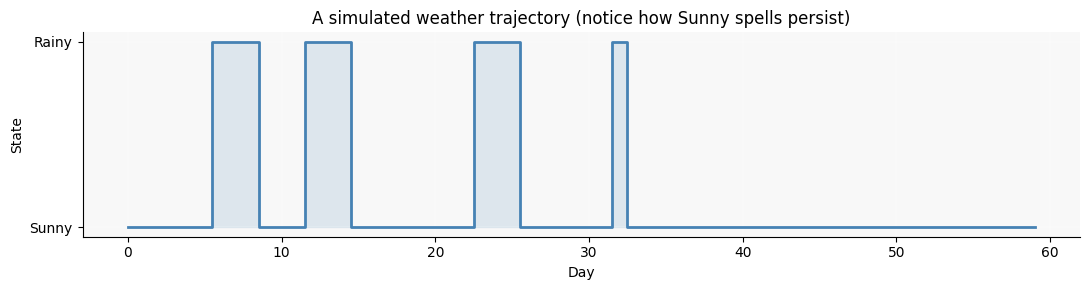

In [5]:
# Plot the simulated trajectory as a step function
fig, ax = plt.subplots(figsize=(11, 3))
ax.step(range(len(path)), path, where="mid", color=C["blue"], lw=2)
ax.fill_between(range(len(path)), path, step="mid", alpha=0.15, color=C["blue"])
ax.set_yticks([0, 1]); ax.set_yticklabels(states)
ax.set_xlabel("Day"); ax.set_ylabel("State")
ax.set_title("A simulated weather trajectory (notice how Sunny spells persist)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4 · The Stationary Distribution — the long-run climate

Run the chain for a *very* long time. What fraction of days are Sunny vs Rainy? That long-run
answer is the **stationary distribution** $\boldsymbol{\pi}$ — a row vector that doesn't change
when you push it through one more step:

$$
\boldsymbol{\pi} P = \boldsymbol{\pi}, \qquad \sum_i \pi_i = 1.
$$

> **Key insight:** $\boldsymbol{\pi}$ is the distribution that is *invariant* under the dynamics.
> If today's uncertainty about the weather already looks like $\boldsymbol{\pi}$, then tomorrow's
> looks exactly the same. It's the **climate** the day-to-day **weather** fluctuates around.

**Two ways to find it:**

- **Algebraically:** $\boldsymbol{\pi}$ is the **left eigenvector** of $P$ with eigenvalue 1.
  (Transpose trick: a left eigenvector of $P$ is a right eigenvector of $P^\top$.)
- **By brute force:** keep multiplying $P$ by itself — the rows of $P^k$ converge to
  $\boldsymbol{\pi}$ (this is *power iteration*, and it's exactly what simulating forever does).

**🎯 Quant flag.** "In the long run, what fraction of time is the system in state X?" is a
**staple** question. It maps directly onto things like the long-run fraction of trading days in
a high-volatility regime. Know both the eigenvector method and the $\pi P = \pi$ definition cold.


In [6]:
def stationary_distribution(P):
    '''Solve pi P = pi via the left eigenvector of P (eigenvalue 1).'''
    # Left eigenvectors of P = right eigenvectors of P^T
    eigvals, eigvecs = np.linalg.eig(P.T)
    # find the eigenvector whose eigenvalue is (closest to) 1
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    pi = pi / pi.sum()          # normalize so the entries sum to 1
    return pi

pi = stationary_distribution(P)
print("Stationary distribution pi:", np.round(pi, 4))
print("Check pi @ P == pi ?      ", np.allclose(pi @ P, pi))

Stationary distribution pi: [0.8333 0.1667]
Check pi @ P == pi ?       True


In [7]:
# Sanity check 1: power iteration (P^k rows converge to pi)
Pk = np.linalg.matrix_power(P, 50)
print("Rows of P^50 (each row -> pi):\n", np.round(Pk, 4))

# Sanity check 2: empirical frequencies from one long simulation
long_path = simulate_markov(P, start=0, n_steps=100_000, rng=rng)
emp = np.array([(long_path == s).mean() for s in range(len(states))])
print("\nEmpirical long-run frequencies:", np.round(emp, 4))
print("Analytic stationary pi:        ", np.round(pi, 4))

Rows of P^50 (each row -> pi):
 [[0.8333 0.1667]
 [0.8333 0.1667]]



Empirical long-run frequencies: [0.8316 0.1684]
Analytic stationary pi:         [0.8333 0.1667]


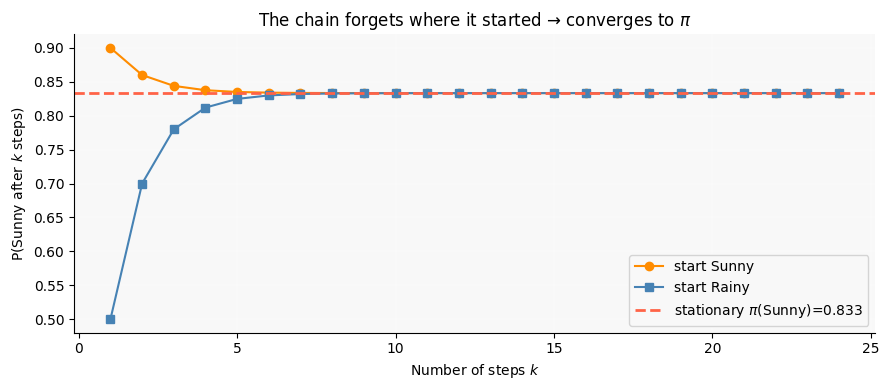

In [8]:
# Visualize convergence: how the rows of P^k approach pi
ks = np.arange(1, 25)
sunny_from_sunny = [np.linalg.matrix_power(P, k)[0, 0] for k in ks]
sunny_from_rainy = [np.linalg.matrix_power(P, k)[1, 0] for k in ks]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, sunny_from_sunny, "o-", color=C["orange"], label="start Sunny")
ax.plot(ks, sunny_from_rainy, "s-", color=C["blue"],   label="start Rainy")
ax.axhline(pi[0], color=C["red"], ls="--", lw=2, label=f"stationary $\\pi$(Sunny)={pi[0]:.3f}")
ax.set_xlabel("Number of steps $k$"); ax.set_ylabel("P(Sunny after $k$ steps)")
ax.set_title("The chain forgets where it started → converges to $\\pi$")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Notice:** both curves forget their starting point and collapse onto the same value
> $\pi_{\text{Sunny}}$. This "forgetting" is called **mixing**, and the speed is governed by the
> **second-largest eigenvalue** of $P$ — another favorite interview detail.


---
## 5 · From visible to **Hidden** — the Hidden Markov Model

So far the state was directly observable (we saw "Sunny"/"Rainy"). But in markets — and in most
of the real world — **the state is hidden**. The market is *secretly* in a Bull or Bear regime;
all *we* see are the noisy daily **returns** it spits out.

A **Hidden Markov Model (HMM)** layers two processes:

- A hidden Markov chain of states $Z_t$ (the regime) — evolves by a transition matrix $A$.
- An observable emission $X_t$ that the *current hidden state* produces by an **emission**
  distribution $B$.

$$
Z_0 \to Z_1 \to Z_2 \to \cdots \quad(\text{hidden})\\
\downarrow\;\;\;\;\downarrow\;\;\;\;\downarrow \\
X_0 \;\;\;\; X_1 \;\;\;\; X_2 \quad(\text{observed})
$$

The two key conditional-independence assumptions (this is the whole model in two lines):

$$
\underbrace{P(Z_t \mid Z_{t-1}, \dots) = P(Z_t \mid Z_{t-1})}_{\text{hidden chain is Markov}},
\qquad
\underbrace{P(X_t \mid Z_t, Z_{<t}, X_{<t}) = P(X_t \mid Z_t)}_{\text{emission depends only on current state}}
$$

| Symbol | Meaning |
| --- | --- |
| $Z_t$ | **hidden** state at time $t$ (the regime: Bull / Bear) |
| $X_t$ | **observed** emission at time $t$ (a discretized daily return) |
| $A_{ij} = P(Z_{t+1}=j \mid Z_t=i)$ | hidden **transition** matrix ($N\times N$) |
| $B_{ik} = P(X_t = k \mid Z_t = i)$ | **emission** matrix ($N\times M$): state $i$ → symbol $k$ |
| $\boldsymbol{\pi}$ | initial state distribution $P(Z_0)$ |

> **Key insight:** An HMM = "a Markov chain wearing a disguise." The chain still obeys the Markov
> property internally, but a noisy emission layer hides the true state. Our job is to *infer the
> disguise's wearer* from the clues $X_t$.

**🎯 Quant flag.** Bull/Bear **regime switching** modeled as an HMM (or its cousin, the
Markov-switching model) is one of *the* canonical applied questions. Be ready to set up
$A$, $B$, $\pi$ for a 2-regime market and explain what each captures.


---
## 6 · A concrete market HMM + generating data

Let's make it tangible. Two hidden regimes:

- **Bull (0):** persistent, mostly positive returns.
- **Bear (1):** persistent, mostly negative returns.

We'll discretize daily returns into **4 observable symbols** (think of these as binned returns):

| symbol $k$ | meaning |
| --- | --- |
| 0 | big down |
| 1 | small down |
| 2 | small up |
| 3 | big up |

Regimes are **sticky** (markets stay in a regime for a while) — that's the strong diagonal in $A$.
The emission matrix $B$ encodes "Bull skews toward up-days, Bear skews toward down-days."


In [9]:
regimes  = ["Bull", "Bear"]
symbols  = ["big-down", "small-down", "small-up", "big-up"]

# Hidden transition matrix A: regimes are sticky (strong diagonal)
A = np.array([[0.95, 0.05],     # Bull tends to stay Bull
              [0.10, 0.90]])    # Bear tends to stay Bear

# Emission matrix B[state, symbol]: P(observation | regime)
#                 bigdn  smdn   smup   bigup
B = np.array([[0.05,  0.20,  0.45,  0.30],   # Bull: skewed to up days
              [0.30,  0.45,  0.20,  0.05]])  # Bear: skewed to down days

pi0 = np.array([0.5, 0.5])      # initial regime is a coin flip

for M_, name in [(A, "A (rows sum to 1)"), (B, "B (rows sum to 1)")]:
    assert np.allclose(M_.sum(axis=1), 1.0), name
print("A =\n", A, "\n\nB =\n", B)

A =
 [[0.95 0.05]
 [0.1  0.9 ]] 

B =
 [[0.05 0.2  0.45 0.3 ]
 [0.3  0.45 0.2  0.05]]


In [10]:
def generate_hmm(A, B, pi0, T, rng):
    '''Sample hidden states z[0..T-1] and observations x[0..T-1] from an HMM.'''
    N, M = B.shape
    z = np.empty(T, dtype=int)
    x = np.empty(T, dtype=int)
    z[0] = rng.choice(N, p=pi0)
    x[0] = rng.choice(M, p=B[z[0]])
    for t in range(1, T):
        z[t] = rng.choice(N, p=A[z[t-1]])    # hidden chain steps
        x[t] = rng.choice(M, p=B[z[t]])      # emission from the new state
    return z, x

T = 200
z_true, x_obs = generate_hmm(A, B, pi0, T, rng)
print("Hidden regimes (first 40):", "".join("B" if s == 0 else "b" for s in z_true[:40]))
print("Observations    (first 40):", x_obs[:40])

Hidden regimes (first 40): BbbbbbbbbbbbbbbbbbbbbbbbbbbBBBBBBBBBBBBB
Observations    (first 40): [1 2 2 2 1 0 1 3 1 1 1 1 1 1 0 1 0 1 2 2 1 2 1 3 1 1 0 1 3 2 0 2 2 2 3 2 1
 1 2 3]


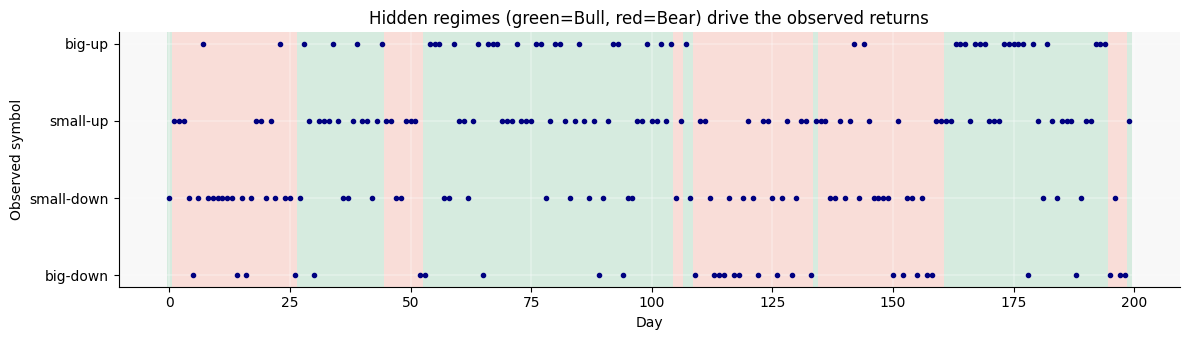

In [11]:
# Visualize: hidden regime shading + observed symbols on top
fig, ax = plt.subplots(figsize=(12, 3.5))
for t in range(T):
    ax.axvspan(t - 0.5, t + 0.5, color=(C["green"] if z_true[t] == 0 else C["red"]),
               alpha=0.18, lw=0)
ax.plot(range(T), x_obs, ".", color=C["navy"], ms=6)
ax.set_yticks(range(4)); ax.set_yticklabels(symbols)
ax.set_xlabel("Day"); ax.set_ylabel("Observed symbol")
ax.set_title("Hidden regimes (green=Bull, red=Bear) drive the observed returns")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Notice the puzzle: the shading (truth) is **hidden** from us in reality. All we get are the navy
dots. The rest of the notebook is about **recovering the hidden colors from the dots.**


---
## 7 · The Forward Algorithm — "how likely is this data?"

**Problem 1 (Evaluation):** given a model $(A, B, \pi)$ and an observation sequence
$X_{0:T-1}$, compute the **likelihood** $P(X_{0:T-1} \mid \text{model})$.

Naively you'd sum over **all** $N^T$ possible hidden paths — exponential, hopeless. The
**Forward algorithm** is the dynamic-programming trick that does it in $O(T N^2)$.

Define the **forward variable**

$$
\alpha_t(i) = P(X_0, X_1, \dots, X_t,\; Z_t = i \mid \text{model}),
$$

read as: *"the joint probability of everything I've seen up to time $t$ **and** being in hidden
state $i$ right now."*

**Recursion (the heart of it):**

$$
\alpha_0(i) = \pi_i \, B_{i, X_0}
$$
$$
\alpha_{t}(j) = \underbrace{\Big[\sum_{i} \alpha_{t-1}(i)\, A_{ij}\Big]}_{\text{all ways to arrive at } j}\; \underbrace{B_{j, X_t}}_{\text{then emit } X_t}
$$

> **Key insight:** $\alpha_t(j)$ folds the entire exponential sum-over-paths into a single vector
> that we carry forward one step at a time. "To be in state $j$ now, I came from *some* state $i$
> (sum over $i$), and then I had to emit what I actually saw ($B_{j,X_t}$)."

The total likelihood is just the final column summed over all states:

$$
P(X_{0:T-1}) = \sum_i \alpha_{T-1}(i).
$$

**Numerical note (interview gold):** the $\alpha$'s shrink toward 0 and **underflow** for long
sequences. The fix is to **rescale** $\alpha_t$ to sum to 1 each step and accumulate
$\log P(X)$ from the scaling factors. We do exactly that below.


In [12]:
def forward(x, A, B, pi0):
    '''Scaled forward algorithm.

    Returns
        alpha_hat : (T, N) normalized forward variables (each row sums to 1)
        loglik    : scalar  log P(observations | model)
    '''
    T = len(x)
    N = A.shape[0]
    alpha_hat = np.zeros((T, N))
    c = np.zeros(T)                       # scaling factors

    # t = 0
    a = pi0 * B[:, x[0]]                  # alpha_0(i) = pi_i * B[i, x0]
    c[0] = a.sum()
    alpha_hat[0] = a / c[0]

    # t = 1 .. T-1
    for t in range(1, T):
        a = (alpha_hat[t-1] @ A) * B[:, x[t]]   # arrive at each state, then emit
        c[t] = a.sum()
        alpha_hat[t] = a / c[t]

    loglik = np.sum(np.log(c))            # log P(X) = sum of log scaling factors
    return alpha_hat, loglik

alpha_hat, loglik = forward(x_obs, A, B, pi0)
print(f"log P(observations | true model) = {loglik:.3f}")

log P(observations | true model) = -257.858


In [13]:
# Why the likelihood matters: it lets us COMPARE models.
# Build a deliberately wrong model (regimes flipped) and compare its likelihood.
A_wrong = np.array([[0.5, 0.5], [0.5, 0.5]])   # "regimes don't persist" model
_, loglik_wrong = forward(x_obs, A_wrong, B, pi0)

print(f"log-lik, TRUE  sticky model : {loglik:10.3f}")
print(f"log-lik, WRONG random model : {loglik_wrong:10.3f}")
print(f"\nThe true (sticky) model assigns the data ~{np.exp(loglik - loglik_wrong):.2e}x "
      f"higher likelihood.")

log-lik, TRUE  sticky model :   -257.858
log-lik, WRONG random model :   -270.595

The true (sticky) model assigns the data ~3.40e+05x higher likelihood.


> **Key insight:** the Forward algorithm turns "does my model explain the data?" into a single
> number you can optimize. Picking the model with the highest log-likelihood is exactly what the
> **Baum-Welch / EM** training algorithm does under the hood (we won't implement full training
> here, but this is the objective it climbs).


---
## 8 · The Viterbi Algorithm — "what was the most likely hidden path?"

**Problem 2 (Decoding):** given the observations, find the single **most probable hidden state
sequence**

$$
Z^\star_{0:T-1} = \arg\max_{z_{0:T-1}} P(z_{0:T-1} \mid X_{0:T-1}).
$$

The Forward algorithm *summed* over paths; Viterbi *maximizes* over them. Same DP skeleton,
replace $\sum$ with $\max$ — and remember **where** the max came from so we can backtrack.

Define

$$
\delta_t(i) = \max_{z_0,\dots,z_{t-1}} P(z_0,\dots,z_{t-1},\, Z_t=i,\; X_0,\dots,X_t),
$$

the probability of the **best** path that ends in state $i$ at time $t$.

**Recursion (in log-space, to avoid underflow):**

$$
\log\delta_t(j) = \max_i\Big[\log\delta_{t-1}(i) + \log A_{ij}\Big] + \log B_{j, X_t}
$$
$$
\psi_t(j) = \arg\max_i\Big[\log\delta_{t-1}(i) + \log A_{ij}\Big] \quad\text{(back-pointer)}
$$

> **Key insight:** $\delta$ asks *"of all ways to be in state $j$ now, which single prior path was
> best?"* The back-pointer $\psi$ remembers that best predecessor so that, once we reach the end,
> we can **walk backwards** and reconstruct the whole winning path.

**🎯 Quant flag.** "Forward sums, Viterbi maxes" is the one-liner that proves you understand both.
Viterbi is the algorithm behind labeling each historical day as Bull/Bear given the model.


In [14]:
def viterbi(x, A, B, pi0):
    '''Viterbi decoding in log-space. Returns the most likely hidden path.'''
    T = len(x)
    N = A.shape[0]
    eps = 1e-12                           # guard against log(0)
    logA  = np.log(A  + eps)
    logB  = np.log(B  + eps)
    logpi = np.log(pi0 + eps)

    delta = np.zeros((T, N))
    psi   = np.zeros((T, N), dtype=int)   # back-pointers

    delta[0] = logpi + logB[:, x[0]]      # init

    for t in range(1, T):
        for j in range(N):
            scores = delta[t-1] + logA[:, j]   # best way to reach j from each i
            psi[t, j]   = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + logB[j, x[t]]

    # Backtrack from the best final state
    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(delta[-1])
    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]
    return path

z_viterbi = viterbi(x_obs, A, B, pi0)
accuracy = (z_viterbi == z_true).mean()
print(f"Viterbi decoding accuracy vs. true hidden regimes: {accuracy:.1%}")

Viterbi decoding accuracy vs. true hidden regimes: 86.5%


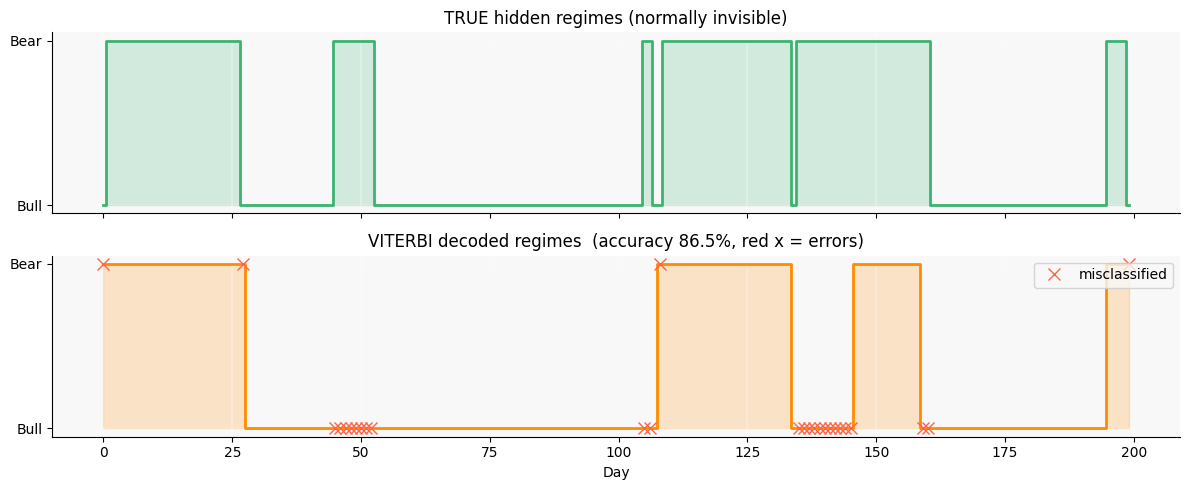

In [15]:
# Compare the decoded path against the (normally hidden) truth
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].step(range(T), z_true, where="mid", color=C["green"], lw=2)
axes[0].fill_between(range(T), z_true, step="mid", alpha=0.2, color=C["green"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(regimes)
axes[0].set_title("TRUE hidden regimes (normally invisible)")
axes[0].grid(alpha=0.3)

axes[1].step(range(T), z_viterbi, where="mid", color=C["orange"], lw=2)
axes[1].fill_between(range(T), z_viterbi, step="mid", alpha=0.2, color=C["orange"])
# mark the days where Viterbi disagrees with truth
wrong = np.where(z_viterbi != z_true)[0]
axes[1].plot(wrong, z_viterbi[wrong], "x", color=C["red"], ms=8, label="misclassified")
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(regimes)
axes[1].set_title(f"VITERBI decoded regimes  (accuracy {accuracy:.1%}, red x = errors)")
axes[1].set_xlabel("Day"); axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> Most errors cluster right at **regime turning points** — exactly where the evidence is
> ambiguous and the model needs a few extra days of confirming returns before it "commits" to the
> switch. That lag is the price of inferring a hidden state from noisy data, and it's a very real
> effect in live regime-detection systems.


---
## 9 · Forward vs. Viterbi — the soft posterior vs. the hard path

The Forward algorithm can also give us a **soft** answer: the probability of being in each regime
on each day. With only the forward pass, the *filtered* posterior is

$$
P(Z_t = i \mid X_{0:t}) = \hat{\alpha}_t(i),
$$

i.e. our normalized forward variable. (The full *smoothed* posterior would also run a backward
pass — the **Forward-Backward** algorithm — but the filtered version already shows the idea.)

Let's plot the soft probability of **Bull** alongside the hard Viterbi call.


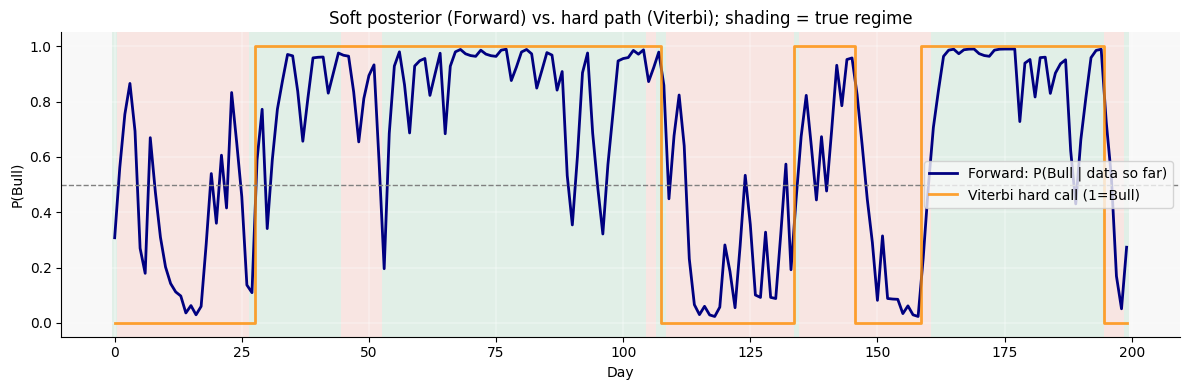

In [16]:
p_bull_filtered = alpha_hat[:, 0]     # P(Bull | data up to t)

fig, ax = plt.subplots(figsize=(12, 4))
# true regime as background shading
for t in range(T):
    ax.axvspan(t - 0.5, t + 0.5, color=(C["green"] if z_true[t] == 0 else C["red"]),
               alpha=0.12, lw=0)
ax.plot(range(T), p_bull_filtered, color=C["navy"], lw=2,
        label="Forward: P(Bull | data so far)")
ax.step(range(T), 1 - z_viterbi, where="mid", color=C["orange"], lw=2, alpha=0.8,
        label="Viterbi hard call (1=Bull)")
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Day"); ax.set_ylabel("P(Bull)")
ax.set_title("Soft posterior (Forward) vs. hard path (Viterbi); shading = true regime")
ax.legend(loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Key insight:** the **soft** posterior expresses *uncertainty* — it drifts toward 0.5 near
> turning points — while **Viterbi** forces a clean 0/1 decision. In trading you often prefer the
> soft probability: it can size positions by *confidence* instead of flipping all-or-nothing.


---
## 10 · Interactive: how regime *stickiness* changes everything

The single most impactful "hyperparameter" here is the **self-transition probability** — how
*sticky* a regime is (the diagonal of $A$). Crank it up and regimes last forever; turn it down and
the chain flickers, making the hidden state nearly impossible to track.

Drag the slider to set the stickiness $p$ (used for **both** regimes' self-transition), then watch
how the generated regimes and the Viterbi decoding accuracy respond.

*(If `ipywidgets` isn't available, the static fallback below runs three fixed values instead.)*


In [17]:
def stickiness_demo(p=0.95, seed=0):
    rng_local = np.random.default_rng(seed)
    A_p = np.array([[p, 1 - p], [1 - p, p]])
    z, x = generate_hmm(A_p, B, pi0, T=200, rng=rng_local)
    z_hat = viterbi(x, A_p, B, pi0)
    acc = (z_hat == z).mean()

    fig, ax = plt.subplots(figsize=(11, 3))
    for t in range(len(z)):
        ax.axvspan(t - 0.5, t + 0.5, color=(C["green"] if z[t] == 0 else C["red"]),
                   alpha=0.18, lw=0)
    ax.step(range(len(z_hat)), z_hat, where="mid", color=C["navy"], lw=1.6,
            label="Viterbi decode")
    ax.set_yticks([0, 1]); ax.set_yticklabels(regimes)
    ax.set_xlabel("Day")
    avg_run = 1 / (1 - p) if p < 1 else np.inf
    ax.set_title(f"stickiness p = {p:.2f}  →  avg regime length ≈ {avg_run:.0f} days   "
                 f"|   Viterbi accuracy = {acc:.1%}")
    ax.legend(loc="upper right"); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(stickiness_demo,
             p=FloatSlider(min=0.50, max=0.99, step=0.01, value=0.95,
                           description="stickiness p"),
             seed=(0, 9))
except Exception as e:
    print(f"(ipywidgets unavailable: {e})\nRunning static fallback for p in {{0.55, 0.85, 0.97}}:")
    for p in (0.55, 0.85, 0.97):
        stickiness_demo(p=p, seed=0)

interactive(children=(FloatSlider(value=0.95, description='stickiness p', max=0.99, min=0.5, step=0.01), IntSl…

> **The takeaway:** expected time spent in a regime before switching is
> $\frac{1}{1 - p}$ (the mean of a geometric distribution — *another* common interview nugget).
> At $p = 0.95$ that's ~20 days; at $p = 0.55$ it's barely 2, and the regimes become noise that
> Viterbi can't recover. **Persistence is what makes hidden states learnable.**


---
## 11 · Summary

We climbed the full ladder: from a fully-observed Markov chain, to its long-run stationary
behavior, to a Hidden Markov Model and the two DP algorithms (**Forward** for likelihood,
**Viterbi** for the best path) that make HMMs useful for regime detection.

| Concept | Key Idea |
| --- | --- |
| **Markov property** | The present state fully summarizes the past: $P(X_{t+1}\mid X_t,\dots)=P(X_{t+1}\mid X_t)$ |
| **Transition matrix $P$** | Row $i$ = distribution over next state given state $i$; rows sum to 1 |
| **Simulation** | Repeatedly draw the next state from the current row of $P$ |
| **Stationary distribution $\pi$** | Long-run state frequencies; solves $\pi P = \pi$; left eigenvector of $P$ |
| **Mixing** | How fast the chain forgets its start; set by the 2nd-largest eigenvalue |
| **Hidden Markov Model** | A Markov chain you can't see, observed only through noisy emissions $B$ |
| **HMM parameters** | $A$ (hidden transitions), $B$ (emissions), $\pi$ (initial state) |
| **Forward algorithm** | $O(TN^2)$ DP for the data likelihood $P(X)$; **sums** over hidden paths |
| **Scaling / log-likelihood** | Rescale $\alpha_t$ each step to avoid underflow; sum log scale factors |
| **Viterbi algorithm** | $O(TN^2)$ DP for the single most likely hidden path; **maxes** over paths |
| **Soft vs. hard** | Forward → posterior probabilities; Viterbi → one hard sequence |
| **Regime stickiness** | Diagonal of $A$; expected regime length $=\frac{1}{1-p}$; persistence ⇒ learnable |

### 🎯 Quant interview cheat-sheet
- **State the Markov property in one sentence.** ("The future is independent of the past given the present.")
- **"Forward sums, Viterbi maxes"** — same DP skeleton, different operator.
- **Stationary distribution** = long-run fraction of time in each state; know $\pi P=\pi$ *and* the eigenvector method.
- **Bull/Bear regime switching** is the textbook HMM application; expected regime length $=1/(1-p)$.
- **Underflow** in the Forward pass → work with scaled $\alpha$'s / log-likelihoods.


---
## 12 · Markov Chain Monte Carlo — running the chain *backwards in logic*

Everything above asked a **forward** question: *given a transition matrix $P$, what stationary
distribution $\pi$ does it settle into?* (Sections 3–4.)

**Markov Chain Monte Carlo (MCMC) flips that arrow.** Now we are *handed* a target distribution
$\pi(x)$ that we want to **sample from**, and we get to **design a Markov chain whose stationary
distribution is exactly that $\pi$.** Then we just run the chain, throw away the warm-up, and treat
the states it visits as samples from $\pi$.

$$
\text{Markov chains (so far):}\quad P \;\longrightarrow\; \pi
\qquad\qquad
\text{MCMC:}\quad \pi \;\longrightarrow\; P
$$

> **Key insight:** If $\pi$ is the stationary distribution of a chain, then *the long-run fraction
> of time the chain spends near each $x$ is proportional to $\pi(x)$* (Section 4!). So a histogram
> of the chain's visited states **is** an estimate of $\pi$. MCMC is "sampling by loitering."

**Why would we ever need this?** Because for most interesting distributions we **cannot** sample
directly. The killer case — and the one quants care about — is a **Bayesian posterior**:

$$
\underbrace{p(\theta \mid \text{data})}_{\text{what we want}}
= \frac{p(\text{data}\mid\theta)\,p(\theta)}{\underbrace{p(\text{data})}_{\text{intractable!}}}
\;\;\propto\;\; p(\text{data}\mid\theta)\,p(\theta).
$$

We can evaluate the numerator (likelihood × prior) easily, but the denominator $p(\text{data})$ —
the **normalizing constant** — is a brutal high-dimensional integral. MCMC's superpower is that it
**never needs that constant**, as we're about to see.

**🎯 Quant flag.** "How do you sample from a distribution you can only evaluate *up to a constant*?"
→ MCMC. Bayesian estimation of model parameters (volatility, factor loadings, regime params) when
the posterior has no closed form is the canonical use case. Knowing *why the normalizing constant
cancels* is the punchline interviewers fish for.


---
## 13 · Detailed balance — the design rule that pins down $\pi$

How do we guarantee our hand-built chain has the *right* stationary distribution? We lean on a
**sufficient condition** that is easy to enforce: **detailed balance** (a.k.a. reversibility).

A chain with transition kernel $P(x \to x')$ satisfies detailed balance w.r.t. $\pi$ if

$$
\boxed{\;\pi(x)\,P(x \to x') \;=\; \pi(x')\,P(x' \to x)\;}\qquad\text{for all } x, x'.
$$

Read it as a **flow-balance** statement: *the probability mass flowing from $x$ to $x'$ exactly
equals the mass flowing back from $x'$ to $x$.* Nothing piles up anywhere — the distribution is in
equilibrium.

**Why detailed balance ⇒ $\pi$ is stationary.** Sum both sides over $x$:

$$
\sum_x \pi(x)\,P(x\to x') = \sum_x \pi(x')\,P(x'\to x)
= \pi(x')\underbrace{\sum_x P(x'\to x)}_{=\,1}
= \pi(x').
$$

The left side is precisely $(\pi P)(x')$ — one step of the chain applied to $\pi$. So
$\pi P = \pi$: **$\pi$ is stationary.** ∎

> **Key insight:** Detailed balance is a *local* condition (one pair $x, x'$ at a time) that buys us
> a *global* guarantee ($\pi$ is stationary). That's what makes it constructive: we only have to
> balance flows pairwise, and the right stationary distribution falls out automatically.

Detailed balance is *sufficient* but not necessary — there are valid MCMC samplers that aren't
reversible — but it's the workhorse that makes **Metropolis-Hastings** almost embarrassingly simple.


---
## 14 · Metropolis-Hastings — propose, then accept or reject

Metropolis-Hastings (MH) builds a detailed-balance chain out of two ingredients:

1. A **proposal distribution** $q(x' \mid x)$ — "given I'm at $x$, where do I *suggest* moving?"
   (e.g. a Gaussian step centered on the current point — a random walk).
2. An **acceptance probability** $A(x \to x')$ — "do I actually take the suggested move?"

The algorithm, one step:

| Step | What you do |
| --- | --- |
| 1. Propose | Draw a candidate $x' \sim q(\cdot \mid x)$ |
| 2. Score | Compute the acceptance ratio $\alpha$ (below) |
| 3. Decide | Draw $u \sim \text{Uniform}(0,1)$; **accept** ($x_{t+1}=x'$) if $u < \alpha$, else **stay** ($x_{t+1}=x$) |

### Deriving the acceptance probability from detailed balance

We *want* detailed balance to hold. The full transition is "propose then accept," so
$P(x\to x') = q(x'\mid x)\,A(x\to x')$. Plug into the balance equation:

$$
\pi(x)\,q(x'\mid x)\,A(x\to x') \;=\; \pi(x')\,q(x\mid x')\,A(x'\to x).
$$

Rearrange for the ratio of acceptances:

$$
\frac{A(x\to x')}{A(x'\to x)} = \frac{\pi(x')\,q(x\mid x')}{\pi(x)\,q(x'\mid x)}.
$$

Metropolis & Hastings make the largest possible choice that respects this ratio (accept as often as
we're allowed, to move efficiently):

$$
\boxed{\;A(x\to x') = \min\!\left(1,\; \frac{\pi(x')\,q(x\mid x')}{\pi(x)\,q(x'\mid x)}\right)\;}
$$

### The two things to notice

**(a) The normalizing constant cancels.** $\pi$ appears only as the *ratio* $\pi(x')/\pi(x)$. If
$\pi(x) = \tilde\pi(x)/Z$ with unknown $Z$, then $Z$ divides out:
$\frac{\pi(x')}{\pi(x)} = \frac{\tilde\pi(x')}{\tilde\pi(x)}$. **We only ever need $\pi$ up to a
constant** — exactly the Bayesian-posterior situation from Section 12.

**(b) Symmetric proposals simplify it.** If the proposal is symmetric, $q(x'\mid x)=q(x\mid x')$
(true for a Gaussian random walk), the $q$'s cancel too and we get the original **Metropolis**
acceptance:

$$
A(x\to x') = \min\!\left(1,\; \frac{\pi(x')}{\pi(x)}\right).
$$

Intuition: *always* accept a move to higher density ($\pi(x') > \pi(x) \Rightarrow \alpha=1$);
accept a move to lower density only *sometimes*, with probability equal to the density ratio. That
controlled willingness to go downhill is what lets the chain explore the whole distribution instead
of collapsing onto the single mode (contrast with hill-climbing optimization).

> **Key insight:** MH needs **only the ability to evaluate $\pi$ up to a constant** and to draw from
> a proposal. No inverse CDF, no normalizing integral. That minimalism is why it works in nasty,
> high-dimensional, un-normalizable settings.

**🎯 Quant flag.** Be ready to (1) write the acceptance ratio from memory, (2) explain *why* the
normalizing constant cancels, and (3) state what changes for an asymmetric proposal (the
$q$-ratio — the "Hastings correction" — reappears).


---
## 15 · Metropolis-Hastings from scratch

Let's sample from a deliberately awkward **bimodal** target — a mixture of two Gaussians — that we
define **only up to a constant** (we tack on an arbitrary factor `42.0` to drive the point home).
Direct sampling formulas don't obviously apply; MH won't care.

$$
\tilde\pi(x) = 42 \cdot \Big[\,0.6\,\mathcal{N}(x;\,-2,\,1^2) + 0.4\,\mathcal{N}(x;\,3,\,0.7^2)\,\Big]
$$

We work in **log-space** (`log_target`) for numerical stability — standard practice, since
densities can be astronomically small.


In [18]:
def log_target(x):
    '''Log of an UNNORMALIZED bimodal density (note the arbitrary 42.0 factor).'''
    comp1 = 0.6 * np.exp(-0.5 * ((x + 2) / 1.0) ** 2)   # N(-2, 1)
    comp2 = 0.4 * np.exp(-0.5 * ((x - 3) / 0.7) ** 2)   # N(3, 0.7)
    return np.log(42.0 * (comp1 + comp2) + 1e-300)      # +tiny to avoid log(0)

def metropolis_hastings(log_target, x0, n_samples, proposal_sd, rng):
    '''Random-walk Metropolis (symmetric Gaussian proposal).

    Returns
        xs       : (n_samples,) the chain's visited states
        acc_rate : fraction of proposals accepted
    '''
    xs = np.empty(n_samples)
    xs[0] = x0
    log_p_curr = log_target(x0)
    n_accept = 0

    for t in range(1, n_samples):
        # 1. Propose a symmetric Gaussian step from the current point
        x_prop = xs[t - 1] + rng.normal(0.0, proposal_sd)
        log_p_prop = log_target(x_prop)

        # 2. Acceptance ratio in log-space: log alpha = log pi(x') - log pi(x)
        #    (symmetric proposal => q-terms cancel; constant 42 cancels in the difference)
        log_alpha = log_p_prop - log_p_curr

        # 3. Accept with prob min(1, alpha); compare log(u) < log_alpha
        if np.log(rng.uniform()) < log_alpha:
            xs[t] = x_prop
            log_p_curr = log_p_prop
            n_accept += 1
        else:
            xs[t] = xs[t - 1]            # rejected -> stay put (this state still counts!)

    return xs, n_accept / (n_samples - 1)

rng = np.random.default_rng(7)
samples, acc_rate = metropolis_hastings(log_target, x0=0.0, n_samples=20_000,
                                        proposal_sd=2.0, rng=rng)
print(f"Acceptance rate: {acc_rate:.1%}")
print(f"Chain mean (post burn-in): {samples[2000:].mean():.3f}")

Acceptance rate: 51.5%
Chain mean (post burn-in): -0.517


### Did it work? Compare the sample histogram to the true (normalized) density

To *check* MH, we normalize the target by numerical integration — but remember, **the sampler never
used this normalization**. It only ever saw `log_target` up to the constant 42.


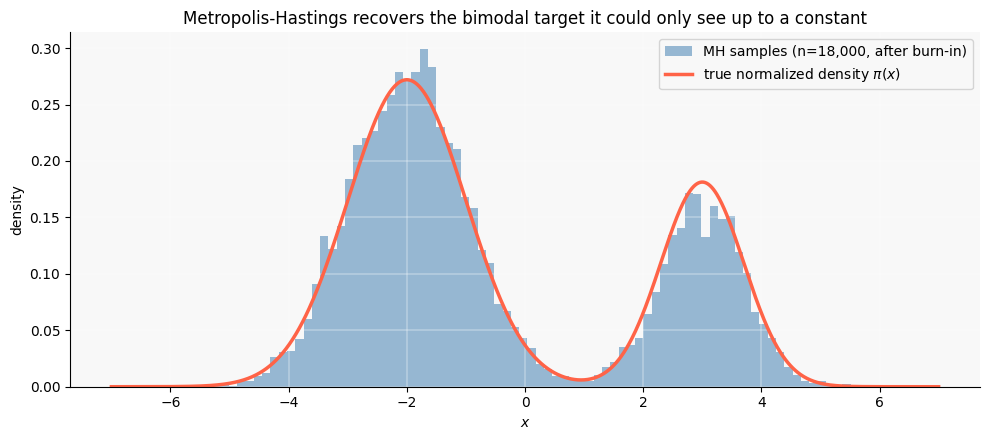

In [19]:
# Build the TRUE normalized density on a grid (for validation only)
grid = np.linspace(-7, 7, 1000)
unnorm = np.exp(np.array([log_target(x) for x in grid]))
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
Z = _trapz(unnorm, grid)              # numerical normalizing constant
true_pdf = unnorm / Z

burn_in = 2000
kept = samples[burn_in:]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(kept, bins=80, density=True, color=C["blue"], alpha=0.55,
        label=f"MH samples (n={len(kept):,}, after burn-in)")
ax.plot(grid, true_pdf, color=C["red"], lw=2.5, label="true normalized density $\\pi(x)$")
ax.set_xlabel("$x$"); ax.set_ylabel("density")
ax.set_title("Metropolis-Hastings recovers the bimodal target it could only see up to a constant")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The trace plot — watching the chain explore

A **trace plot** shows the chain's value over iterations. A healthy random-walk MH chain should
wander across the *whole* support and visibly **hop between both modes**, not get stuck in one.


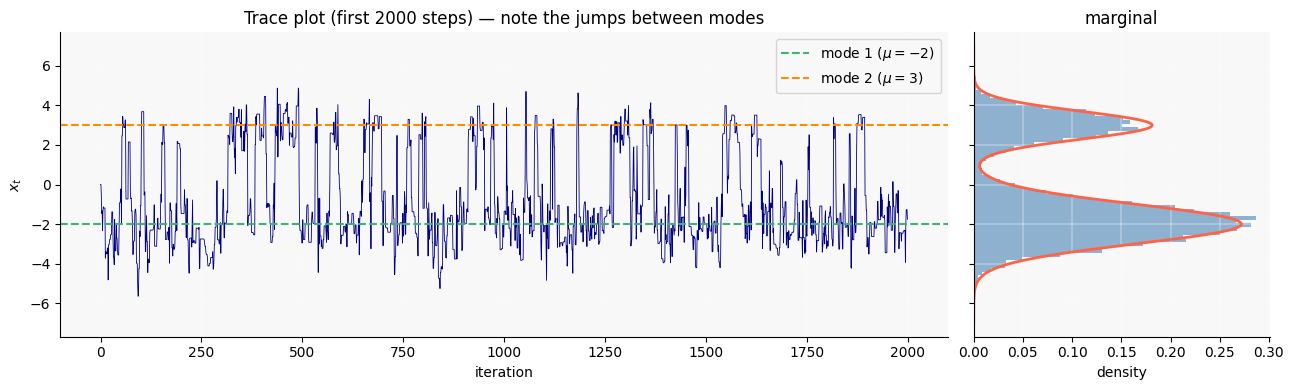

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4),
                               gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

ax1.plot(samples[:2000], color=C["navy"], lw=0.6)
ax1.axhline(-2, color=C["green"], ls="--", lw=1.5, label="mode 1 ($\\mu=-2$)")
ax1.axhline(3,  color=C["orange"], ls="--", lw=1.5, label="mode 2 ($\\mu=3$)")
ax1.set_xlabel("iteration"); ax1.set_ylabel("$x_t$")
ax1.set_title("Trace plot (first 2000 steps) — note the jumps between modes")
ax1.legend(loc="upper right"); ax1.grid(alpha=0.3)

ax2.hist(kept, bins=60, density=True, orientation="horizontal",
         color=C["blue"], alpha=0.6)
ax2.plot(true_pdf, grid, color=C["red"], lw=2)
ax2.set_xlabel("density"); ax2.set_title("marginal")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 16 · The one knob that matters — proposal step size

The proposal standard deviation (step size) is MCMC's most consequential tuning parameter. It
creates a classic trade-off:

- **Step too small** → almost every move is accepted (you barely move, so $\pi(x')\approx\pi(x)$),
  but the chain **crawls**: it takes forever to cross the distribution and explores poorly. High
  acceptance, terrible mixing.
- **Step too large** → proposals routinely leap into near-zero-density regions and get **rejected**,
  so the chain **stands still** for long stretches. Low acceptance, terrible mixing.
- **Just right** → big enough to traverse the distribution, small enough to keep getting accepted.

There's even folklore guidance: for high-dimensional targets the **optimal acceptance rate is
≈ 0.234**; for a 1-D target it's closer to **≈ 0.44**. Let's *see* the trade-off.


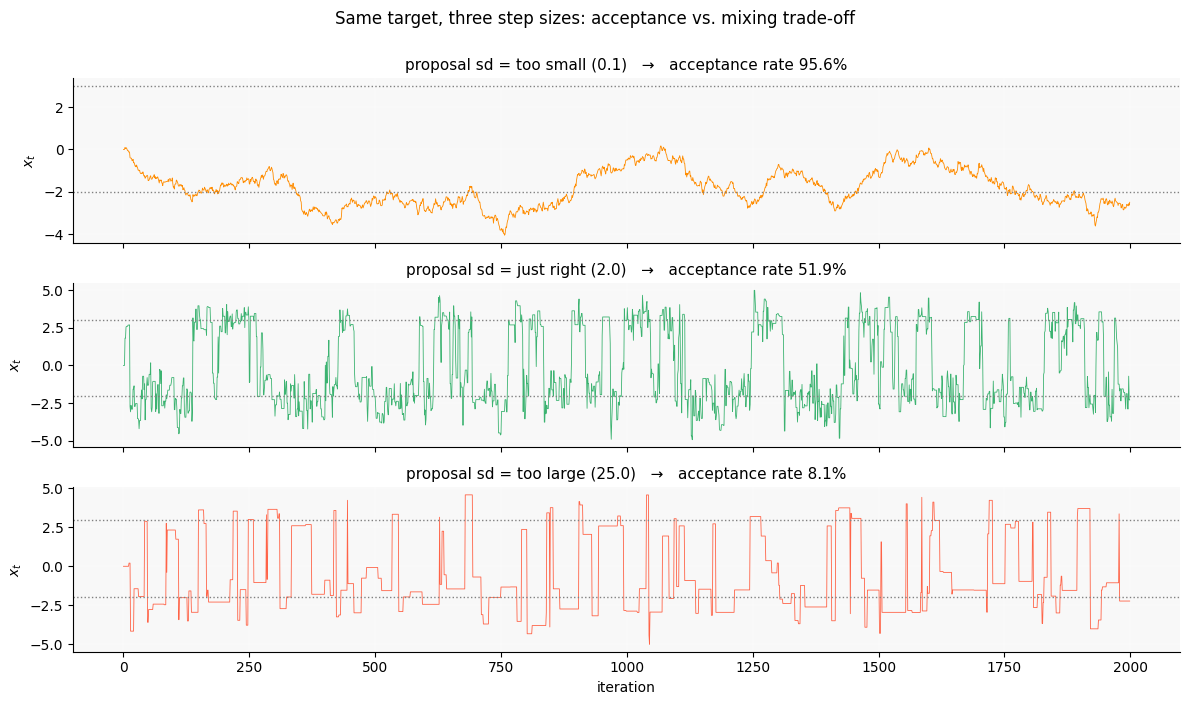

In [21]:
def run_and_summarize(proposal_sd, seed=1, n=10_000):
    rng_local = np.random.default_rng(seed)
    xs, acc = metropolis_hastings(log_target, x0=0.0, n_samples=n,
                                  proposal_sd=proposal_sd, rng=rng_local)
    return xs, acc

step_sizes = [0.1, 2.0, 25.0]
labels = ["too small (0.1)", "just right (2.0)", "too large (25.0)"]
colors = [C["orange"], C["green"], C["red"]]

fig, axes = plt.subplots(len(step_sizes), 1, figsize=(12, 7), sharex=True)
for ax, sd, lab, col in zip(axes, step_sizes, labels, colors):
    xs, acc = run_and_summarize(sd)
    ax.plot(xs[:2000], color=col, lw=0.6)
    ax.axhline(-2, color="gray", ls=":", lw=1); ax.axhline(3, color="gray", ls=":", lw=1)
    ax.set_ylabel("$x_t$")
    ax.set_title(f"proposal sd = {lab}   →   acceptance rate {acc:.1%}", fontsize=11)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("iteration")
fig.suptitle("Same target, three step sizes: acceptance vs. mixing trade-off", y=1.0)
plt.tight_layout()
plt.show()

> **Read the panels:** the *too-small* chain (top) oozes around one region and rarely reaches the
> far mode — acceptance near 100% but useless exploration. The *too-large* chain (bottom) shows long
> flat horizontal runs — those are **rejections** where it froze in place. The *middle* chain mixes
> briskly between both modes. **High acceptance is not the goal; good mixing is.**

### Interactive: feel the trade-off yourself


In [22]:
def mcmc_demo(proposal_sd=2.0, seed=1):
    xs, acc = run_and_summarize(proposal_sd, seed=seed, n=8000)
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.6),
                                   gridspec_kw={"width_ratios": [2, 1]})
    axL.plot(xs[:1500], color=C["navy"], lw=0.6)
    axL.axhline(-2, color=C["green"], ls="--", lw=1)
    axL.axhline(3,  color=C["orange"], ls="--", lw=1)
    axL.set_xlabel("iteration"); axL.set_ylabel("$x_t$")
    axL.set_title(f"trace  |  acceptance {acc:.1%}")
    axL.grid(alpha=0.3)

    axR.hist(xs[1000:], bins=60, density=True, color=C["blue"], alpha=0.55)
    axR.plot(grid, true_pdf, color=C["red"], lw=2)
    axR.set_xlabel("$x$"); axR.set_title("samples vs $\\pi(x)$")
    axR.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(mcmc_demo,
             proposal_sd=FloatSlider(min=0.1, max=25.0, step=0.1, value=2.0,
                                     description="proposal sd"),
             seed=(0, 9))
except Exception as e:
    print(f"(ipywidgets unavailable: {e})\nStatic fallback for sd in {{0.1, 2.0, 25.0}}:")
    for sd in (0.1, 2.0, 25.0):
        mcmc_demo(proposal_sd=sd)

interactive(children=(FloatSlider(value=2.0, description='proposal sd', max=25.0, min=0.1), IntSlider(value=1,…

---
## 17 · MCMC Summary

MCMC inverts the Markov-chain logic from the first half of this notebook: instead of asking what
$\pi$ a given chain converges to, we **engineer a chain whose stationary $\pi$ is our target**, then
sample by running it. Metropolis-Hastings does this with nothing more than a proposal and an
accept/reject coin flip — and crucially needs the target **only up to a normalizing constant.**

| Concept | Key Idea |
| --- | --- |
| **MCMC** | Sample from $\pi$ by building a Markov chain whose stationary distribution **is** $\pi$, then loitering |
| **Why** | Direct sampling impossible for most posteriors; normalizing constant $p(\text{data})$ is intractable |
| **Detailed balance** | $\pi(x)P(x\to x')=\pi(x')P(x'\to x)$ ⇒ $\pi$ is stationary (local rule, global guarantee) |
| **Metropolis-Hastings** | Propose $x'\sim q$, accept w.p. $\min\!\big(1,\frac{\pi(x')q(x\mid x')}{\pi(x)q(x'\mid x)}\big)$ |
| **Normalizing constant** | Cancels in the ratio $\pi(x')/\pi(x)$ — need $\pi$ only up to a constant |
| **Symmetric proposal** | $q$ cancels ⇒ Metropolis: accept w.p. $\min(1,\pi(x')/\pi(x))$ |
| **Acceptance rule** | Always go uphill; go downhill *sometimes* — that's what enables full exploration |
| **Burn-in** | Discard the early transient before the chain reaches stationarity |
| **Proposal step size** | The key knob: too small → crawls; too large → rejects; tune for **mixing**, not high acceptance |
| **Optimal acceptance** | Rule of thumb ≈ 0.234 (high-dim), ≈ 0.44 (1-D) |

### 🎯 Quant interview cheat-sheet (MCMC)
- **Write the MH acceptance ratio from memory** and explain each term.
- **Why does the normalizing constant cancel?** Because $\pi$ enters only as a ratio — the punchline for Bayesian posteriors.
- **Detailed balance ⇒ stationarity** — be able to give the one-line proof (sum over $x$).
- **Symmetric vs. asymmetric proposal** — the Hastings $q$-ratio correction appears only when $q$ is asymmetric.
- **Diagnosing a chain** — trace plots, burn-in, acceptance rate; *high acceptance ≠ good mixing*.
- **Connection to this notebook** — same $\pi P=\pi$ idea as Section 4, just run in reverse.
